In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

Mean Absolute Error (2023 예측): 147.37434285714286


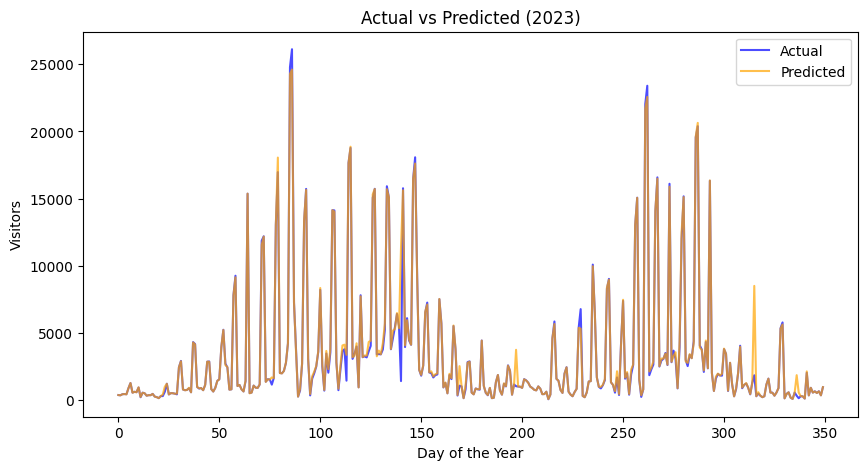

In [2]:
import pandas as pd
from datetime import datetime

# 1. 공휴일 및 대체공휴일 정의 함수
def get_holidays(year):
    holidays_dict = {
        2018: [
            '2018-01-01', '2018-02-15', '2018-02-16', '2018-02-17',  # 신정, 설날
            '2018-03-01', '2018-05-05', '2018-05-07',               # 삼일절, 어린이날 대체공휴일
            '2018-06-06', '2018-08-15', '2018-09-23', '2018-09-24', '2018-09-25',  # 현충일, 광복절, 추석
            '2018-10-03', '2018-10-09', '2018-12-25'                # 개천절, 한글날, 성탄절
        ],
        2019: [
            '2019-01-01', '2019-02-04', '2019-02-05', '2019-02-06',  # 신정, 설날
            '2019-03-01', '2019-05-05', '2019-05-06',               # 삼일절, 어린이날 대체공휴일
            '2019-06-06', '2019-08-15', '2019-09-12', '2019-09-13', '2019-09-14',  # 현충일, 광복절, 추석
            '2019-10-03', '2019-10-09', '2019-12-25'                # 개천절, 한글날, 성탄절
        ],
        2020: [
            '2020-01-01', '2020-01-24', '2020-01-25', '2020-01-26', '2020-01-27',  # 신정, 설날, 대체공휴일
            '2020-03-01', '2020-04-15', '2020-05-05',               # 삼일절, 총선, 어린이날
            '2020-06-06', '2020-08-15', '2020-09-30', '2020-10-01', '2020-10-02',  # 현충일, 광복절, 추석
            '2020-10-03', '2020-10-09', '2020-12-25'                # 개천절, 한글날, 성탄절
        ],
        2021: [
            '2021-01-01', '2021-02-11', '2021-02-12', '2021-02-13',  # 신정, 설날
            '2021-03-01', '2021-05-05', '2021-05-19',               # 삼일절, 어린이날, 부처님오신날
            '2021-06-06', '2021-08-15', '2021-08-16',               # 광복절, 대체공휴일
            '2021-09-20', '2021-09-21', '2021-09-22',               # 추석
            '2021-10-03', '2021-10-09', '2021-12-25'                # 개천절, 한글날, 성탄절
        ],
        2022: [
            '2022-01-01', '2022-01-31', '2022-02-01', '2022-02-02',  # 신정, 설날
            '2022-03-01', '2022-05-05', '2022-05-08', '2022-05-09',  # 삼일절, 어린이날, 부처님오신날, 대체공휴일
            '2022-06-06', '2022-08-15',                              # 현충일, 광복절
            '2022-09-09', '2022-09-10', '2022-09-11', '2022-09-12',  # 추석, 대체공휴일
            '2022-10-03', '2022-10-09', '2022-10-10', '2022-12-25'   # 개천절, 한글날, 대체공휴일, 성탄절
        ],
        2023: [
            '2023-01-01', '2023-01-21', '2023-01-22', '2023-01-23',  # 신정, 설날
            '2023-03-01', '2023-05-05', '2023-05-27',               # 삼일절, 어린이날, 부처님오신날
            '2023-06-06', '2023-08-15',                              # 현충일, 광복절
            '2023-09-28', '2023-09-29', '2023-09-30', '2023-10-03',  # 추석, 개천절
            '2023-10-09', '2023-12-25'                               # 한글날, 성탄절
        ]
    }
    return [datetime.strptime(date, '%Y-%m-%d') for date in holidays_dict[year]]

# 2. 공휴일 추가 및 전처리 함수
def add_holiday_column(df, year):
    holiday_dates = get_holidays(year)
    df['date'] = pd.to_datetime(df['date'])
    df['is_holiday'] = df['date'].apply(lambda x: 1 if x in holiday_dates else 0)
    return df

# 3. 데이터 로드 및 전처리
file_paths = {
    2018: '서울대공원_입장객_정보_2018년_day_한글복원2.csv',
    2019: '서울대공원_입장객_정보_2019년_day_한글복원 (1).csv',
    2020: '서울대공원_입장객_정보_2020년_day_한글복원_new.csv',
    2021: '서울대공원_입장객_정보_2021년_day_한글복원.csv',
    2022: '서울대공원_입장객_정보_2022년_day_한글복원.csv',
    2023: '서울대공원_입장객_정보_2023년_day_한글복원.csv'
}

data_frames = []
for year, path in file_paths.items():
    try:
        # 인코딩을 CP949로 지정하여 파일 읽기
        df = pd.read_csv(path, encoding='cp949')
    except UnicodeDecodeError:
        # 필요시 다른 인코딩 시도 (예: utf-8)
        df = pd.read_csv(path, encoding='utf-8')
    
    df = add_holiday_column(df, year)  # 공휴일 추가
    df = df[df['is_holiday'] == 0]  # 공휴일 제거
    df['year'] = year
    data_frames.append(df)


# 4. 데이터 병합
data = pd.concat(data_frames)

# 4. Feature와 Target 분리
X = data.drop(columns=['individual_visitors'])  # Feature
y = data['individual_visitors']  # Target

# 필요한 경우, 날짜 등의 비정형 데이터를 전처리
# 여기서는 'date' 열을 'day', 'month' 등으로 나누는 예시 제공
X['date'] = pd.to_datetime(X['date'])
X['day'] = X['date'].dt.day
X['month'] = X['date'].dt.month
X = X.drop(columns=['date'])

# 5. 학습 및 테스트 데이터 분리
X_train = X[X['year'] < 2023]
X_test = X[X['year'] == 2023]
y_train = y[X['year'] < 2023]
y_test = y[X['year'] == 2023]

# 6. 모델 학습
model = RandomForestRegressor(n_estimators = 100, random_state=42)
model.fit(X_train, y_train)

# 7. 예측 및 평가
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (2023 예측): {mae}")

# 8. 결과 시각화 
# 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual', color='blue', alpha=0.7)  # 투명도 설정
plt.plot(y_pred, label='Predicted', color='orange', alpha=0.7)  # 투명도 설정
plt.legend()
plt.title('Actual vs Predicted (2023)')
plt.xlabel('Day of the Year')
plt.ylabel('Visitors')
plt.show()


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 예측 및 실제값
y_pred = model.predict(X_test)

# 평가 지표 계산
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 결과 출력
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.3f}")


Mean Absolute Error (MAE): 147.37
Mean Squared Error (MSE): 487929.89
Root Mean Squared Error (RMSE): 698.52
R² Score: 0.978


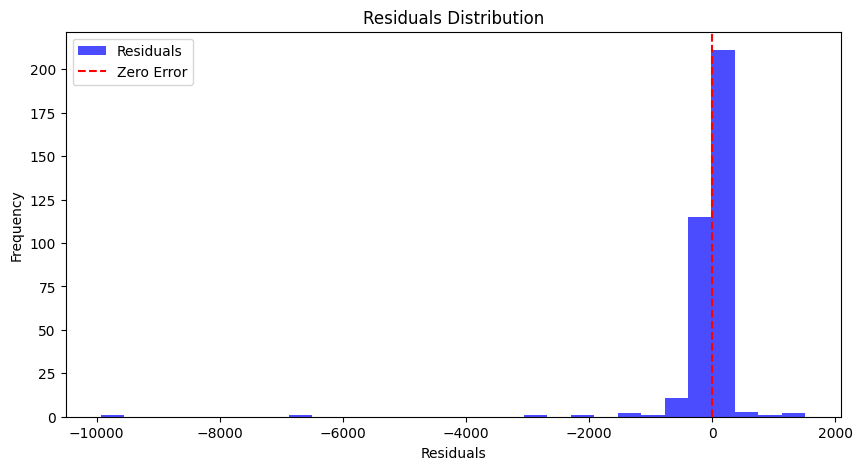

In [4]:
import matplotlib.pyplot as plt

# 잔차 계산
residuals = y_test - y_pred

# 잔차 분포 시각화
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=30, alpha=0.7, color='blue', label='Residuals')
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.legend()
plt.show()


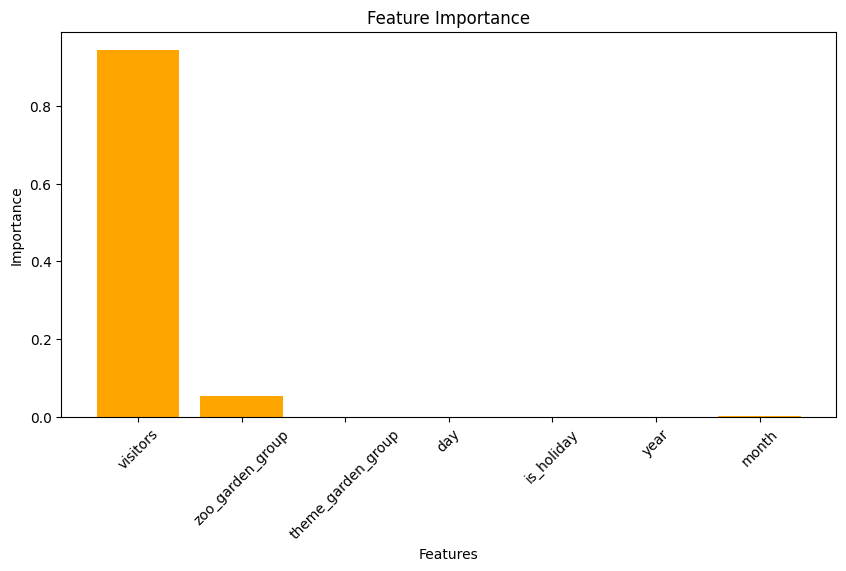

In [5]:
# Feature Importance 시각화
importances = model.feature_importances_
features = X_train.columns

plt.figure(figsize=(10, 5))
plt.bar(features, importances, color='orange')
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()


In [6]:
# 학습 데이터와 테스트 데이터의 연도 분리 여부 확인
print("학습 데이터 연도 확인:", X_train['year'].unique())
print("테스트 데이터 연도 확인:", X_test['year'].unique())

# 학습 데이터와 테스트 데이터의 크기 확인
print("학습 데이터 크기:", X_train.shape, y_train.shape)
print("테스트 데이터 크기:", X_test.shape, y_test.shape)


학습 데이터 연도 확인: [2018 2019 2020 2021 2022]
테스트 데이터 연도 확인: [2023]
학습 데이터 크기: (1745, 7) (1745,)
테스트 데이터 크기: (350, 7) (350,)


In [7]:
# 와, 대박! 예측 성공

In [8]:
# 이걸로 개인 방문객 예측은 완벽해졌다

In [9]:
# 날씨 => 큰 변수가 되지 못했다 그냥 넣었다
# 단체예약 => 이게 큰 변수다 그래서 빼버렸다 단체는 적용이 실시간으로 적용가능하니 뺌
# 공휴일 및 대체공휴일 => 이건 음력으로 계산하는 한국 특성상 음력이라 매년 달라지므로 뺌

In [10]:
#이제 단체 빈도 예측 공휴일 예측이 남았다


In [11]:
X_train

,visitors,zoo_garden_group,theme_garden_group,day,is_holiday,year,month
1,988.0,119.0,0.0,2,0,2018,1
2,694.0,0.0,0.0,3,0,2018,1
3,671.0,1.0,0.0,4,0,2018,1
4,758.0,0.0,0.0,5,0,2018,1
5,1935.0,0.0,0.0,6,0,2018,1
...,...,...,...,...,...,...,...
360,345.0,0.0,0.0,27,0,2022,12
361,442.0,0.0,0.0,28,0,2022,12
362,394.0,0.0,0.0,29,0,2022,12
363,2546.0,2039.0,0.0,30,0,2022,12


In [12]:
X_test

,visitors,zoo_garden_group,theme_garden_group,day,is_holiday,year,month
1,365.0,0.0,0.0,2,0,2023,1
2,345.0,0.0,0.0,3,0,2023,1
3,428.0,0.0,0.0,4,0,2023,1
4,439.0,0.0,0.0,5,0,2023,1
5,424.0,0.0,0.0,6,0,2023,1
...,...,...,...,...,...,...,...
360,643.0,0.0,0.0,27,0,2023,12
361,518.0,0.0,0.0,28,0,2023,12
362,651.0,0.0,0.0,29,0,2023,12
363,344.0,0.0,0.0,30,0,2023,12


In [13]:
y_train

1       869.0
2       694.0
3       670.0
4       758.0
5      1935.0
        ...  
360     345.0
361     442.0
362     394.0
363     507.0
364     970.0
Name: individual_visitors, Length: 1745, dtype: float64

In [14]:
y_test

1      365.0
2      345.0
3      428.0
4      439.0
5      424.0
       ...  
360    643.0
361    518.0
362    651.0
363    344.0
364    950.0
Name: individual_visitors, Length: 350, dtype: float64